To implement a Logistic Regression model using Gradient Descent to predict whether a person is likely to develop diabetes within the next 5 years based on health parameters, and to evaluate the model’s performance using accuracy.


In [ ]:
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


In [ ]:
data = pd.read_csv("pima_indians_diabetes.csv")

X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values


In [ ]:
scaler = MinMaxScaler()
X = scaler.fit_transform(X)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def gradient_descent(X, y, learning_rate, epochs):

    n_samples, n_features = X.shape

    weights = np.zeros(n_features)
    bias = 0

    for epoch in range(epochs):

        for i in range(n_samples):

            linear_model = np.dot(X[i], weights) + bias
            y_pred = sigmoid(linear_model)

            error = y_pred - y[i]

            for j in range(n_features):
                weights[j] = weights[j] - learning_rate * error * X[i][j]

            bias = bias - learning_rate * error

    return weights, bias


In [ ]:
weights, bias = gradient_descent(X_train, y_train, 0.01, 1000)


In [ ]:
def predict(X, weights, bias):

    y_pred = []

    for i in range(len(X)):
        linear_model = np.dot(X[i], weights) + bias
        prediction = sigmoid(linear_model)

        if prediction >= 0.5:
            y_pred.append(1)
        else:
            y_pred.append(0)

    return np.array(y_pred)


In [ ]:
predictions = predict(X_test, weights, bias)


Confusion Matrix:
[[78 21]
 [18 37]]


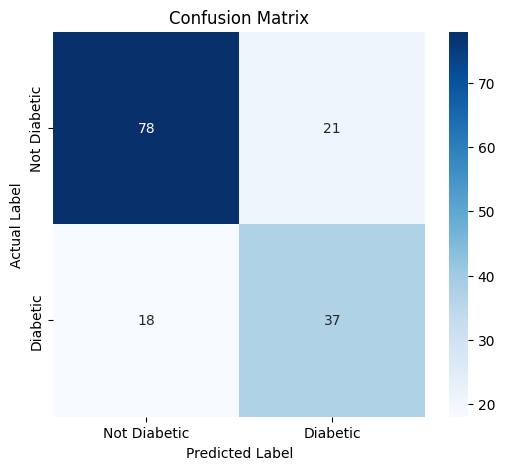

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, predictions)

print("Confusion Matrix:")
print(cm)
plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=["Not Diabetic", "Diabetic"],
            yticklabels=["Not Diabetic", "Diabetic"])

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
for i in range(len(predictions)):
    print("Actual:", y_test[i], " Predicted:", predictions[i])


Actual: 0  Predicted: 0
Actual: 0  Predicted: 0
Actual: 0  Predicted: 0
Actual: 0  Predicted: 0
Actual: 0  Predicted: 0
Actual: 0  Predicted: 0
Actual: 0  Predicted: 0
Actual: 0  Predicted: 1
Actual: 0  Predicted: 1
Actual: 0  Predicted: 1
Actual: 1  Predicted: 0
Actual: 0  Predicted: 1
Actual: 1  Predicted: 0
Actual: 0  Predicted: 0
Actual: 0  Predicted: 0
Actual: 1  Predicted: 0
Actual: 0  Predicted: 0
Actual: 0  Predicted: 0
Actual: 1  Predicted: 1
Actual: 1  Predicted: 1
Actual: 0  Predicted: 0
Actual: 0  Predicted: 0
Actual: 0  Predicted: 1
Actual: 0  Predicted: 0
Actual: 0  Predicted: 1
Actual: 1  Predicted: 1
Actual: 0  Predicted: 0
Actual: 0  Predicted: 0
Actual: 1  Predicted: 0
Actual: 0  Predicted: 0
Actual: 1  Predicted: 1
Actual: 1  Predicted: 1
Actual: 1  Predicted: 1
Actual: 1  Predicted: 1
Actual: 0  Predicted: 1
Actual: 1  Predicted: 1
Actual: 1  Predicted: 1
Actual: 1  Predicted: 0
Actual: 0  Predicted: 1
Actual: 1  Predicted: 1
Actual: 0  Predicted: 0
Actual: 0  Predi

In [ ]:
predictions = predict(X_test, weights, bias)

accuracy = np.sum(predictions == y_test) / len(y_test)

print("Test Accuracy:", accuracy * 100, "%")


Test Accuracy: 74.67532467532467 %
